<a href="https://colab.research.google.com/github/ravitkurakula/RaviGPT/blob/main/RaviGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [25]:
with open("/content/drive/MyDrive/RaviGPT/data/tiny-shakespeare.txt", 'r', encoding = "utf-8") as f :
  text = f.read()



In [26]:
class CharTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for i, ch in enumerate(self.chars)}

    @property
    def vocab_size(self):
        return len(self.chars)

    def encode(self, text):
        return [self.stoi[ch] for ch in text]

    def decode(self, tokens):
        return ''.join(self.itos[token] for token in tokens)

In [27]:
tokenizer = CharTokenizer(text)
data = tokenizer.encode(text)

In [29]:
# Model configuration

block_size = 64
batch_size = 32

d_model = 128
num_heads = 4
d_ff = 512
num_blocks = 4

dropout = 0.1

vocab_size = tokenizer.vocab_size

In [30]:
n = int(0.9 *len(data))

train_data = torch.tensor(data[:n],dtype= torch.long)
val_data = torch.tensor(data[n:],dtype=torch.long)


In [31]:
def get_batch(split):
    data = train_data if split == "train" else val_data

    ix = torch.randint(
        len(data) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        data[i:i + block_size]
        for i in ix
    ])

    y = torch.stack([
        data[i + 1:i + block_size + 1]
        for i in ix
    ])

    return x, y

In [32]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_model,num_heads,dropout=0.1):
    super().__init__()

    self.dropout = nn.Dropout(dropout)
    self.d_model = d_model
    self.num_heads = num_heads
    self.head_dim = d_model // num_heads

    self.W_Q = nn.Linear(d_model,d_model)
    self.W_K = nn.Linear(d_model,d_model)
    self.W_V = nn.Linear(d_model,d_model)

    self.out_proj  = nn.Linear(d_model,d_model)

  def forward(self,x,mask):
    B,T,C = x.shape

    q = self.W_Q(x)
    k = self.W_K(x)
    v = self.W_V(x)

    q= q.view(B,T,self.num_heads,self.head_dim)
    k= k.view(B,T,self.num_heads,self.head_dim)
    v= v.view(B,T,self.num_heads,self.head_dim)

    q= q.transpose(1,2)
    k= k.transpose(1,2)
    v= v.transpose(1,2)

    scores = q@k.transpose(-2,-1)
    scores = scores/(self.head_dim**0.5)

    scores = scores.masked_fill(mask == 0, float('-inf'))
    attention_weights = torch.softmax(scores,dim=-1)
    attention_weights = self.dropout(attention_weights)
    output = attention_weights@v

    output = output.transpose(1,2)
    output = output.contiguous().view(B,T,self.d_model)

    output = self.out_proj(output)

    return output

In [33]:
class TransformerBlock(nn.Module):
  def __init__(self,d_model,num_heads,d_ff,dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(dropout)
    self.ln1 = nn.LayerNorm(d_model)
    self.attention = MultiHeadAttention(d_model,num_heads)
    self.ln2 = nn.LayerNorm(d_model)

    self.fc1 = nn.Linear(d_model,d_ff)
    self.fc2 = nn.Linear(d_ff,d_model)

  def forward(self,x,mask) :
      normalized_x = self.ln1(x)
      attention_output = self.attention(normalized_x,mask)
      attention_output = self.dropout(attention_output)
      x= x + attention_output
      normalized_x = self.ln2(x)

      hidden = self.fc1(normalized_x)
      hidden = torch.nn.functional.gelu(hidden)

      mlp_output = self.fc2(hidden)
      mlp_output = self.dropout(mlp_output)

      x = x + mlp_output

      return x


In [34]:
class TransformersStack(nn.Module):
  def __init__(self,num_blocks,d_model,num_heads,d_ff):
    super().__init__()

    self.blocks = nn.ModuleList([
        TransformerBlock(d_model,num_heads,d_ff) for _ in range(num_blocks)
    ])

  def forward(self,x,mask):
    for block in self.blocks:
      x = block(x,mask)
    return x

In [38]:
class TransformerLanguageModel(nn.Module):
  def __init__(self,vocab_size,d_model,num_heads,d_ff,num_blocks,block_size):
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size,d_model)
    self.position_embedding = nn.Embedding(block_size,d_model)
    self.stack = TransformersStack(
        num_blocks,
        d_model,
        num_heads,
        d_ff
    )
    self.final_ln = nn.LayerNorm(d_model)
    self.lm_head = nn.Linear(d_model,vocab_size)

  def forward(self,x,mask):
    T = x.size(1)
    positions = torch.arange(T,device = x.device)
    token_emb = self.token_embedding(x)
    position_emb = self.position_embedding(positions)

    x = token_emb+position_emb
    x= self.stack(x,mask)
    x = self.final_ln(x)
    logits = self.lm_head(x)

    return logits

  @torch.no_grad()
  def generate(self, x, max_new_tokens, block_size=64,temperature = 1.0,top_k=None):

    for _ in range(max_new_tokens):

        x_cond = x[:, -block_size:]

        T = x_cond.size(1)

        mask = torch.tril(
            torch.ones(T, T, device=x.device)
        )

        logits = self(x_cond, mask)

        next_token_logits = logits[:, -1, :]

        if top_k is not None:
          values,_ = torch.topk(next_token_logits,top_k)
          min_value = values[:,-1].unsqueeze(-1)
          next_token_logits[next_token_logits < min_value] = float("-inf")

        probs = F.softmax(next_token_logits/temperature, dim=-1)

        next_token = torch.multinomial(probs, num_samples=1)

        x = torch.cat((x, next_token), dim=1)

    return x

In [39]:
model = TransformerLanguageModel(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    num_blocks=num_blocks,
    block_size=block_size
)

In [40]:
print(sum(p.numel() for p in model.parameters()))

818241


In [41]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4
)

In [42]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr= 3e-4
)

In [43]:
@torch.no_grad()
def estimate_loss():

    model.eval()

    losses = {}

    for split in ["train", "val"]:
        split_losses = []

        for _ in range(10):
            x, y = get_batch(split)

            T = x.size(1)

            mask = torch.tril(
                torch.ones(T, T, device=x.device)
            )

            logits = model(x, mask)

            B, T, V = logits.shape

            logits = logits.view(B * T, V)
            y = y.view(B * T)

            loss = F.cross_entropy(logits, y)

            split_losses.append(loss.item())

        losses[split] = sum(split_losses) / len(split_losses)

    model.train()

    return losses

In [44]:
model.train()

max_steps = 1000
eval_interval = 100

train_losses = []
val_losses = []
eval_steps = []

for step in range(max_steps):

    # Evaluate periodically
    if step % eval_interval == 0:
        losses = estimate_loss()

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        eval_steps.append(step)

        print(
            f"Step {step}: "
            f"train loss = {losses['train']:.4f}, "
            f"val loss = {losses['val']:.4f}"
        )

    # Get training batch
    x, y = get_batch("train")

    T = x.size(1)

    mask = torch.tril(
        torch.ones(T, T, device=x.device)
    )

    # Forward pass
    logits = model(x, mask)

    B, T, V = logits.shape

    loss = F.cross_entropy(
        logits.view(B * T, V),
        y.view(B * T)
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

Step 0: train loss = 4.3387, val loss = 4.3330
Step 100: train loss = 2.6056, val loss = 2.6342
Step 200: train loss = 2.5027, val loss = 2.4987
Step 300: train loss = 2.4076, val loss = 2.4099
Step 400: train loss = 2.3439, val loss = 2.3609
Step 500: train loss = 2.2771, val loss = 2.2947
Step 600: train loss = 2.2045, val loss = 2.2415
Step 700: train loss = 2.1445, val loss = 2.1604
Step 800: train loss = 2.1005, val loss = 2.1288
Step 900: train loss = 2.0758, val loss = 2.1062


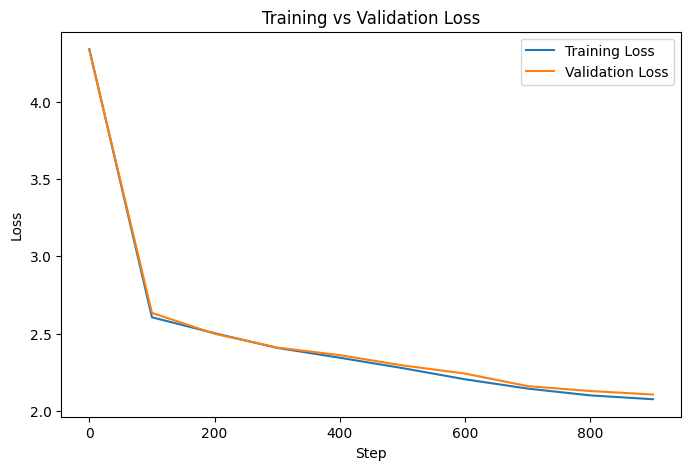

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(eval_steps, train_losses, label="Training Loss")
plt.plot(eval_steps, val_losses, label="Validation Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()